# Robust Regression, GLMs, and Quantile Regression

**Flow:** outliers break OLS → robust estimators (Huber, RANSAC, Theil-Sen) → the wrong noise model → generalized linear models for counts (Poisson) and positive skewed targets (Gamma/Tweedie) → predicting a quantile instead of the mean.

Ordinary least squares assumes roughly Gaussian, constant-variance noise and is very sensitive to outliers. When those assumptions fail, we have better tools: **robust regressors** that downweight or ignore outliers, **generalized linear models (GLMs)** that match the target's distribution and link, and **quantile regression** that models a chosen percentile rather than the mean.


## 1. Setup and versions

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import (LinearRegression, HuberRegressor, RANSACRegressor,
    TheilSenRegressor, PoissonRegressor, GammaRegressor, TweedieRegressor, QuantileRegressor)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    mean_poisson_deviance, mean_gamma_deviance, mean_pinball_loss)

rng = np.random.default_rng(11)


## 2. Outliers wreck OLS
We build a clean linear relationship, then corrupt a handful of training points with large vertical outliers. Split happens before fitting. OLS chases the outliers because squared error penalizes large residuals heavily.

In [3]:
n = 120
x = np.linspace(0, 10, n)
y_clean = 2.0 + 1.3 * x
y = y_clean + rng.normal(0, 0.8, size=n)
X = x[:, None]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Corrupt ~8% of TRAINING points with large outliers (test stays clean for honest scoring).
n_out = max(3, int(0.08 * len(y_train)))
idx = rng.choice(len(y_train), size=n_out, replace=False)
y_train_corrupt = y_train.copy()
y_train_corrupt[idx] += rng.normal(0, 18, size=n_out)
print(f'Injected {n_out} outliers into the training set.')


Injected 6 outliers into the training set.


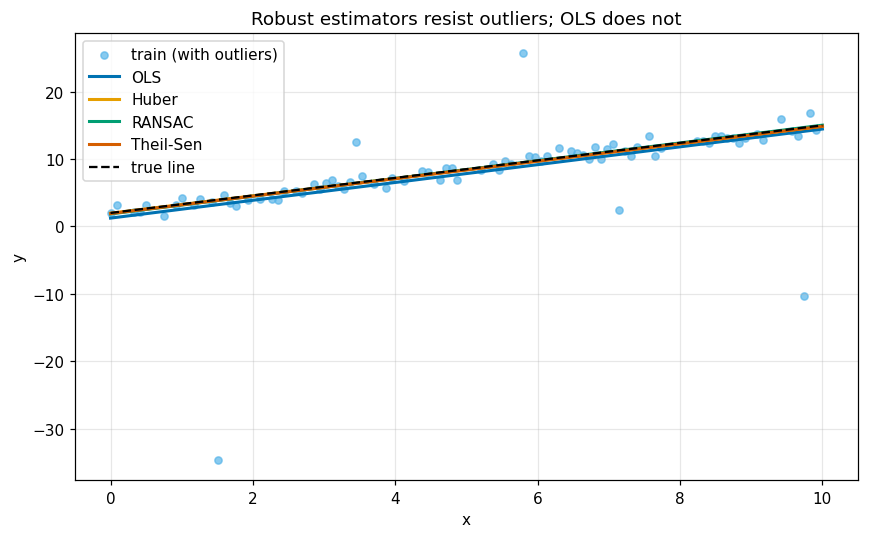

In [4]:
models = {
    'OLS': LinearRegression(),
    'Huber': HuberRegressor(epsilon=1.35),
    'RANSAC': RANSACRegressor(random_state=0),
    'Theil-Sen': TheilSenRegressor(random_state=0),
}
grid = np.linspace(0, 10, 200)[:, None]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[:, 0], y_train_corrupt, s=22, color=OKABE_ITO[5], alpha=0.7, label='train (with outliers)')
for i, (name, mdl) in enumerate(models.items()):
    mdl.fit(X_train, y_train_corrupt)
    ax.plot(grid[:, 0], mdl.predict(grid), color=OKABE_ITO[i], lw=2, label=name)
ax.plot(grid[:, 0], 2.0 + 1.3 * grid[:, 0], color=OKABE_ITO[7], lw=1.5, ls='--', label='true line')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Robust estimators resist outliers; OLS does not')
ax.legend(); plt.tight_layout(); plt.show()


## 3. Held-out comparison of robust estimators
We score every model on the **clean** held-out test set. Robust methods recover the true slope far better than OLS when the training data is contaminated.

In [5]:
print(f'{"model":12s}{"test RMSE":>12s}{"test MAE":>12s}{"slope":>10s}')
for name, mdl in models.items():
    p = mdl.predict(X_test)
    slope = mdl.estimator_.coef_[0] if name == 'RANSAC' else mdl.coef_[0]
    print(f'{name:12s}{mean_squared_error(y_test, p, squared=False):>12.3f}'
          f'{mean_absolute_error(y_test, p):>12.3f}{slope:>10.3f}')
print('\nTrue slope = 1.300')


model          test RMSE    test MAE     slope
OLS                1.160       1.024     1.322
Huber              0.793       0.680     1.289
RANSAC             0.774       0.660     1.317
Theil-Sen          0.802       0.689     1.295

True slope = 1.300


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root 

## 4. Count targets: Poisson GLM instead of OLS
When the target is a **non-negative count**, OLS can predict negative values and assumes constant variance. A **Poisson GLM** uses a log link (`mean = exp(Xb)`), guaranteeing positive predictions and modeling variance that grows with the mean. We generate counts from a true Poisson process and compare.

In [6]:
m = 400
xa = rng.uniform(-1, 1, size=m)
xb = rng.uniform(-1, 1, size=m)
Xc = np.column_stack([xa, xb])
lin_pred = 1.0 + 0.9 * xa - 0.6 * xb          # linear predictor (log-mean)
mu = np.exp(lin_pred)                           # true mean via log link
y_count = rng.poisson(mu)                       # Poisson counts
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, y_count, test_size=0.3, random_state=3)

ols = LinearRegression().fit(Xc_tr, yc_tr)
pois = PoissonRegressor(alpha=1e-4, max_iter=500).fit(Xc_tr, yc_tr)
ols_pred = ols.predict(Xc_te)
pois_pred = pois.predict(Xc_te)
print(f'OLS     : negatives predicted = {(ols_pred < 0).sum()}, '
      f'Poisson deviance = {mean_poisson_deviance(yc_te, np.clip(ols_pred, 1e-6, None)):.3f}')
print(f'Poisson : negatives predicted = {(pois_pred < 0).sum()}, '
      f'Poisson deviance = {mean_poisson_deviance(yc_te, pois_pred):.3f}')


OLS     : negatives predicted = 5, Poisson deviance = 2.232
Poisson : negatives predicted = 0, Poisson deviance = 1.095


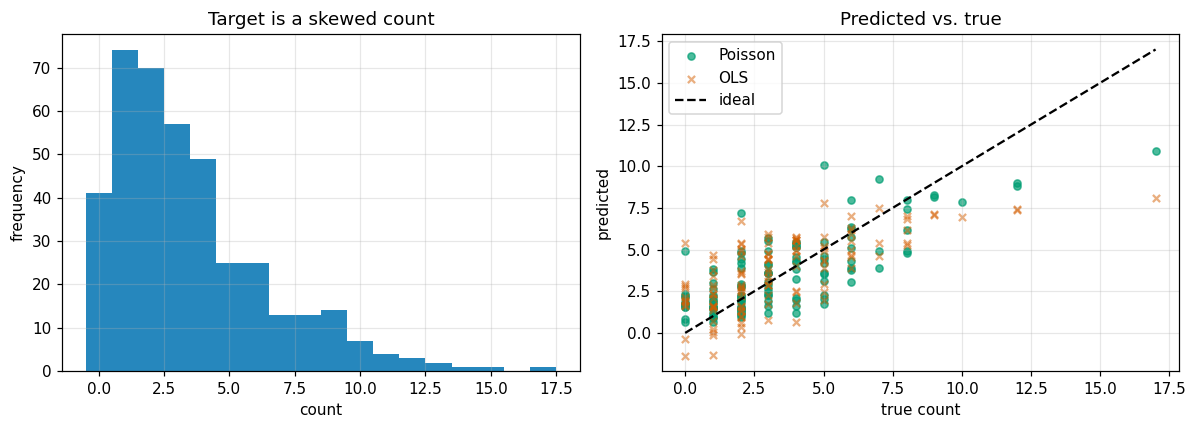

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(y_count, bins=range(0, y_count.max() + 2), color=OKABE_ITO[0], alpha=0.85, align='left')
ax[0].set_xlabel('count'); ax[0].set_ylabel('frequency'); ax[0].set_title('Target is a skewed count')
ax[1].scatter(yc_te, pois_pred, s=22, color=OKABE_ITO[2], alpha=0.7, label='Poisson')
ax[1].scatter(yc_te, ols_pred, s=22, color=OKABE_ITO[3], alpha=0.5, marker='x', label='OLS')
lims = [min(yc_te.min(), 0), yc_te.max()]
ax[1].plot(lims, lims, color=OKABE_ITO[7], ls='--', label='ideal')
ax[1].set_xlabel('true count'); ax[1].set_ylabel('predicted'); ax[1].set_title('Predicted vs. true')
ax[1].legend(); plt.tight_layout(); plt.show()


## 5. Positive skewed targets: Gamma / Tweedie GLM
For strictly **positive, right-skewed** targets (costs, insurance claim size, rainfall) a **Gamma GLM** (log link) models constant *coefficient of variation*. `TweedieRegressor` generalizes this: `power=0` is Gaussian (OLS), `power=1` is Poisson, `power=2` is Gamma, and `1<power<2` handles the common zero-inflated positive case. We fit Gamma and an equivalent Tweedie and compare deviance.

In [8]:
mu_g = np.exp(0.5 + 0.8 * xa - 0.5 * xb)     # positive mean
shape_k = 3.0
y_pos = rng.gamma(shape_k, mu_g / shape_k)   # Gamma-distributed positive target
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xc, y_pos, test_size=0.3, random_state=4)

gamma = GammaRegressor(alpha=1e-4, max_iter=500).fit(Xg_tr, yg_tr)
tweedie = TweedieRegressor(power=2, alpha=1e-4, max_iter=500).fit(Xg_tr, yg_tr)
ols_g = LinearRegression().fit(Xg_tr, yg_tr)
for name, mdl in [('OLS', ols_g), ('Gamma', gamma), ('Tweedie(p=2)', tweedie)]:
    p = np.clip(mdl.predict(Xg_te), 1e-6, None)
    print(f'{name:14s} gamma deviance={mean_gamma_deviance(yg_te, p):.4f}  '
          f'RMSE={mean_squared_error(yg_te, p, squared=False):.3f}')


OLS            gamma deviance=0.3526  RMSE=1.020
Gamma          gamma deviance=0.3089  RMSE=1.015
Tweedie(p=2)   gamma deviance=0.3089  RMSE=1.015


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 6. Quantile regression: model a percentile, not the mean
`QuantileRegressor` minimizes the **pinball loss** to predict a chosen quantile. This is ideal for **heteroscedastic** data (spread grows with x) and for prediction intervals. We fit the 10th, 50th, and 90th percentiles and show the widening band. Tuning note: the regularization strength `alpha` can be selected with CV using the pinball loss for the target quantile.

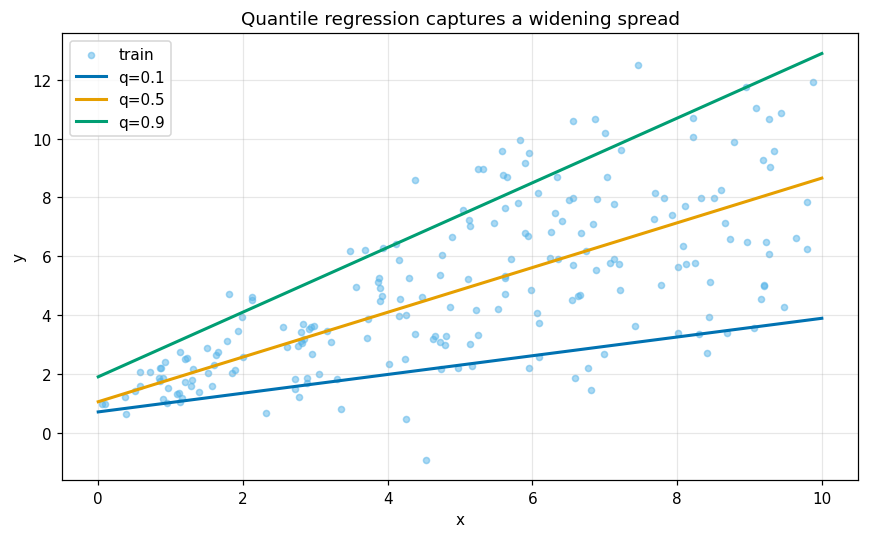

q=0.1: held-out pinball loss = 0.367
q=0.5: held-out pinball loss = 0.799
q=0.9: held-out pinball loss = 0.330

Empirical coverage of the 10-90% band on held-out data: 81.11% (target ~80%)


In [9]:
xa2 = np.sort(rng.uniform(0, 10, size=300))
noise_scale = 0.4 + 0.35 * xa2               # variance grows with x (heteroscedastic)
y_h = 1.0 + 0.8 * xa2 + rng.normal(0, 1, size=xa2.size) * noise_scale
Xh = xa2[:, None]
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, y_h, test_size=0.3, random_state=5)

gridh = np.linspace(0, 10, 200)[:, None]
quantiles = [0.1, 0.5, 0.9]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(Xh_tr[:, 0], yh_tr, s=16, color=OKABE_ITO[5], alpha=0.5, label='train')
preds_te = {}
for i, q in enumerate(quantiles):
    qr = QuantileRegressor(quantile=q, alpha=1e-3, solver='highs').fit(Xh_tr, yh_tr)
    ax.plot(gridh[:, 0], qr.predict(gridh), color=OKABE_ITO[i], lw=2, label=f'q={q}')
    preds_te[q] = qr.predict(Xh_te)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Quantile regression captures a widening spread')
ax.legend(); plt.tight_layout(); plt.show()

for q in quantiles:
    print(f'q={q}: held-out pinball loss = {mean_pinball_loss(yh_te, preds_te[q], alpha=q):.3f}')
cover = np.mean((yh_te >= preds_te[0.1]) & (yh_te <= preds_te[0.9]))
print(f'\nEmpirical coverage of the 10-90% band on held-out data: {cover:.2%} (target ~80%)')


## Key takeaways and caveats

- **Robust regressors** (Huber, RANSAC, Theil-Sen) resist outliers. Huber downweights large residuals; RANSAC fits on inlier subsets; Theil-Sen uses median-of-slopes. Use them when contamination is plausible; they are not free lunch when the bulk of the data is genuinely noisy.
- **Match the GLM to the target.** Counts to Poisson (log link, positive predictions, mean-variance link); positive skewed values to Gamma or Tweedie. OLS on such targets can predict impossible values and misstate uncertainty. Compare models with the appropriate **deviance**, not just RMSE.
- **`TweedieRegressor` unifies these:** power 0=Gaussian, 1=Poisson, 2=Gamma, and 1<p<2 for zero-inflated positive data.
- **Quantile regression** predicts a percentile via pinball loss, giving prediction intervals and handling heteroscedasticity. Fitted quantiles can occasionally cross with limited data; check empirical coverage on held-out data.
- Always split before fitting and select any regularization strength with cross-validation using a loss matched to the task.
